In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import pairwise_distances
import os
import umap.umap_ as umap
import seaborn as sns
import pandas as pd

In [10]:
X_train = pd.read_csv(
    "train_in - Copy.csv",
    header=None
).values

y_train = pd.read_csv(
    "train_out - Copy.csv",
    header=None
).values.ravel()

Centers shape: (10, 256)


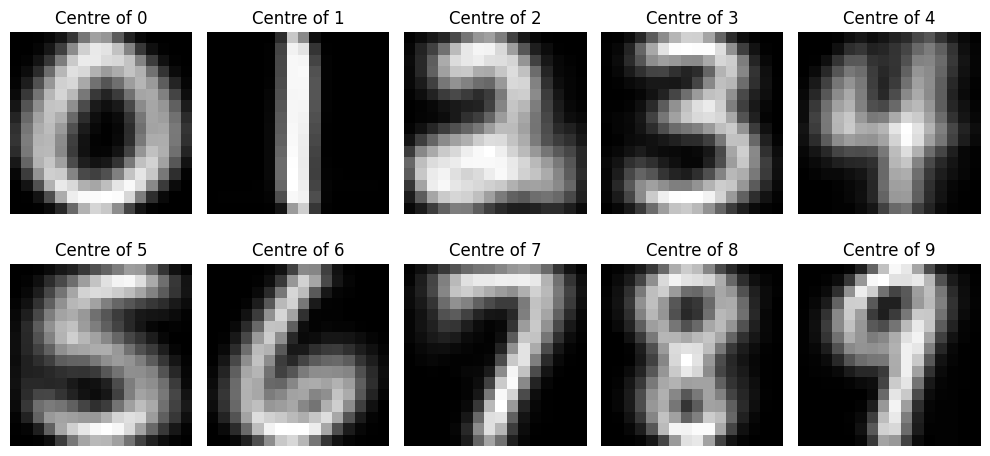

In [11]:
centers = []

for digit in range(10):

    digit_images = X_train[y_train == digit]

    center = digit_images.mean(axis=0)

    centers.append(center)

centers = np.array(centers)

print("Centers shape:", centers.shape)

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for digit in range(10):

    center_image = centers[digit].reshape(16, 16)

    axes.ravel()[digit].imshow(
        center_image,
        cmap="gray"
    )

    axes.ravel()[digit].set_title(
        f"Centre of {digit}"
    )

    axes.ravel()[digit].axis("off")

plt.tight_layout()
plt.show()


[[ 0.         14.44960797  9.33455587  9.14373367 10.76984444  7.51929626
   8.15444313 11.86455505  9.90790174 11.48887494]
 [14.44960797  0.         10.12532258 11.7332329  10.17378643 11.11880041
  10.61470037 10.74315367 10.08677677  9.9320937 ]
 [ 9.33455587 10.12532258  0.          8.17828489  7.93254148  7.90679632
   7.33180754  8.87253107  7.07751618  8.88774785]
 [ 9.14373367 11.7332329   8.17828489  0.          9.0876078   6.11875002
   9.30206473  8.92240093  7.02042489  8.35435012]
 [10.76984444 10.17378643  7.93254148  9.0876078   0.          8.00151741
   8.78223265  7.58301228  7.38090899  6.01040793]
 [ 7.51929626 11.11880041  7.90679632  6.11875002  8.00151741  0.
   6.69869172  9.21195402  6.96738648  8.25853807]
 [ 8.15444313 10.61470037  7.33180754  9.30206473  8.78223265  6.69869172
   0.         10.8882374   8.58722228 10.44000352]
 [11.86455505 10.74315367  8.87253107  8.92240093  7.58301228  9.21195402
  10.8882374   0.          8.4677853   5.42647412]
 [ 9.907

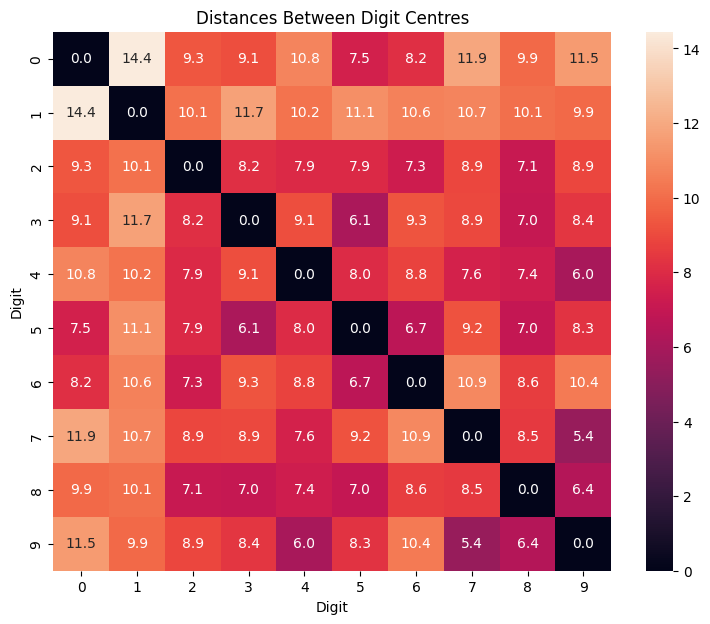

In [12]:
distance_matrix = pairwise_distances(
    centers,
    metric="euclidean"
)

print(distance_matrix)

plt.figure(figsize=(9, 7))

sns.heatmap(
    distance_matrix,
    annot=True,
    fmt=".1f",
    xticklabels=range(10),
    yticklabels=range(10)
)

plt.xlabel("Digit")
plt.ylabel("Digit")
plt.title("Distances Between Digit Centres")

plt.show()

In [13]:
closest_pairs = []

for i in range(10):
    for j in range(i + 1, 10):

        distance = distance_matrix[i, j]

        closest_pairs.append(
            (distance, i, j)
        )

closest_pairs.sort()

for distance, digit1, digit2 in closest_pairs[:5]:

    print(
        f"Digits {digit1} and {digit2}: "
        f"distance = {distance:.2f}"
    )


Digits 7 and 9: distance = 5.43
Digits 4 and 9: distance = 6.01
Digits 3 and 5: distance = 6.12
Digits 8 and 9: distance = 6.40
Digits 5 and 6: distance = 6.70


In [14]:
X_test = pd.read_csv(
    "test_in - Copy.csv",
    header=None
).values

y_test = pd.read_csv(
    "test_out - Copy.csv",
    header=None
).values.ravel()

X_all = np.vstack([
    X_train,
    X_test
])

y_all = np.concatenate([
    y_train,
    y_test
])

print(X_all.shape)
print(y_all.shape)

(2707, 256)
(2707,)


(2707, 2)


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/decomposition/_pca.py:604: RuntimeWarning: divide by zero encountered in matmul
  C = X.T @ X
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/decomposition/_pca.py:604: RuntimeWarning: overflow encountered in matmul
  C = X.T @ X
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/decomposition/_pca.py:604: RuntimeWarning: invalid value encountered in matmul
  C = X.T @ X
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/Library/Frameworks/Python.framework/Versions/3

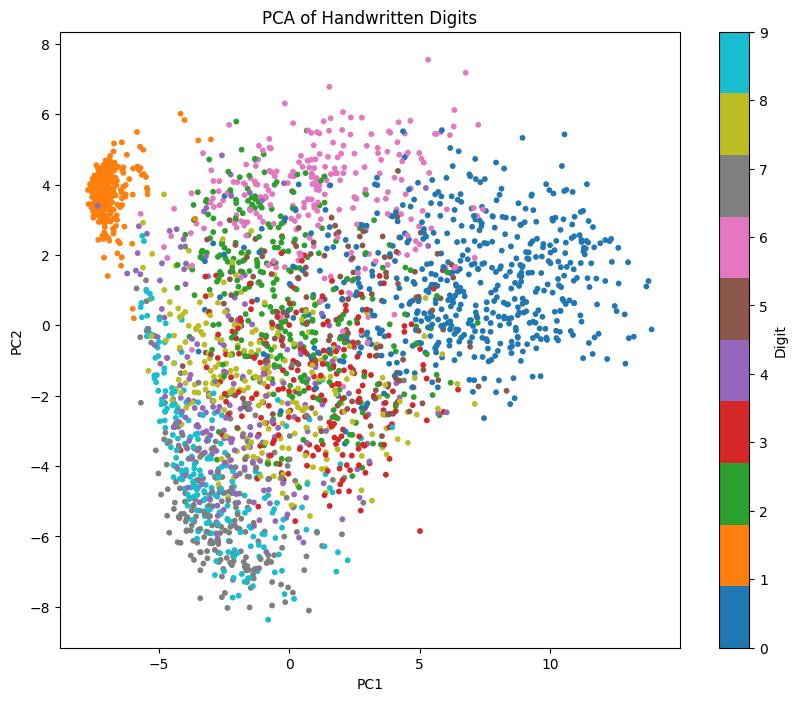

In [15]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_all)

print(X_pca.shape)

plt.figure(figsize=(10, 8))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=y_all,
    cmap="tab10",
    s=10
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of Handwritten Digits")

plt.colorbar(label="Digit")

plt.show()


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


(2707, 2)


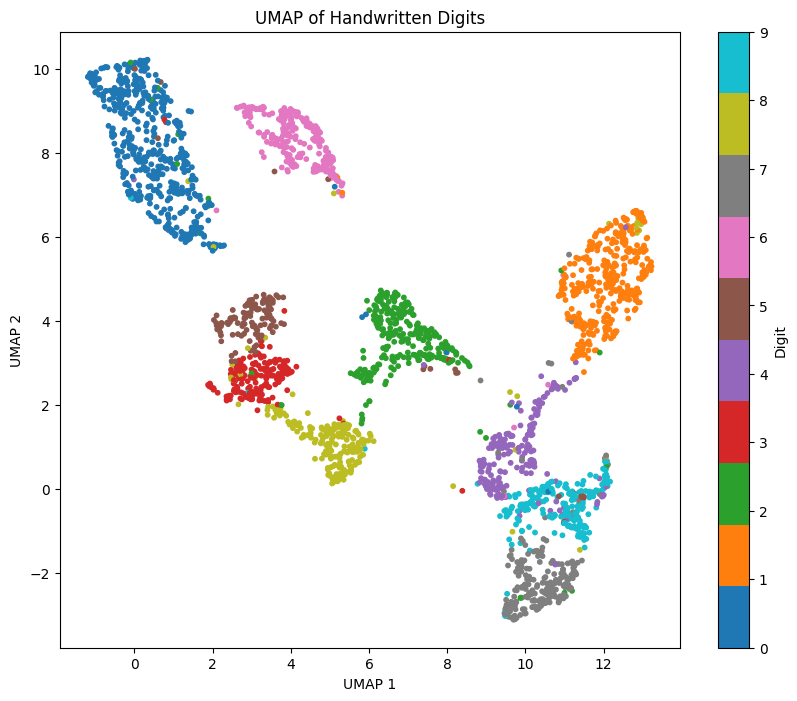

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A @ Q)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A @ Q)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: invalid value encountered in matmul
  Q, _ = normalizer(A @ Q)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:351: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:351: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Library/Frameworks/Python.framework/Versions/3.13/lib/pyth

(2707, 2)


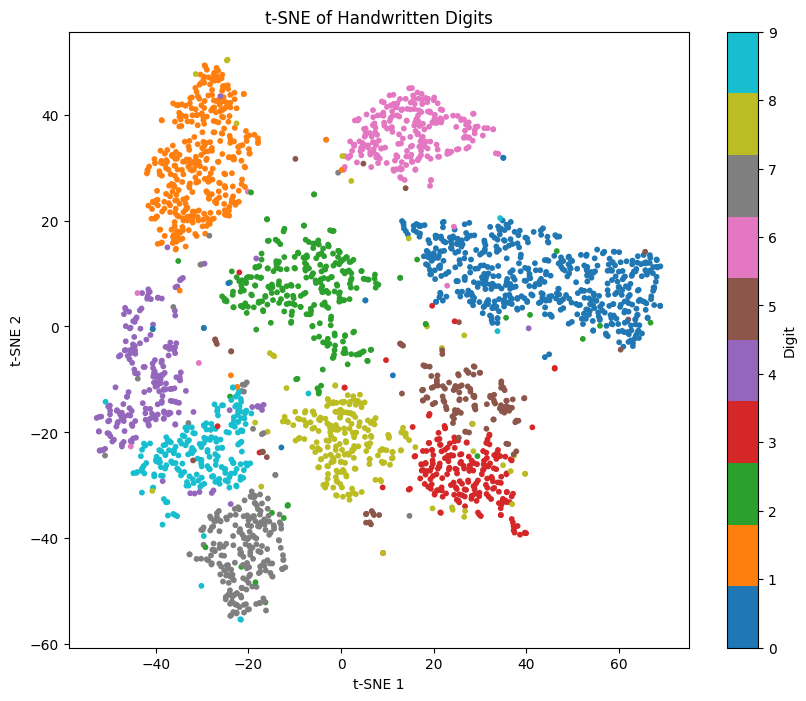

In [16]:
umap_model = umap.UMAP(
    n_components=2,
    random_state=42
)

X_umap = umap_model.fit_transform(X_all)

print(X_umap.shape)

plt.figure(figsize=(10, 8))

plt.scatter(
    X_umap[:, 0],
    X_umap[:, 1],
    c=y_all,
    cmap="tab10",
    s=10
)

plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.title("UMAP of Handwritten Digits")

plt.colorbar(label="Digit")

plt.show()

tsne = TSNE(
    n_components=2,
    random_state=42,
    init="pca",
    learning_rate="auto"
)

X_tsne = tsne.fit_transform(X_all)

print(X_tsne.shape)

plt.figure(figsize=(10, 8))

plt.scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    c=y_all,
    cmap="tab10",
    s=10
)

plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("t-SNE of Handwritten Digits")

plt.colorbar(label="Digit")

plt.show()